# Business Problem :Customer Churn & Fulfillment Friction
### •Problem Statement
Context: High one-time customer churn and increasing support complaints regarding delivery and experience.

Hypothesis: Fulfillment bottlenecks (e.g., shipping delays, high freight costs) drive customer attrition.

Goal: Quantify churn, identify root causes using Olist data, and build a predictive retention model.


### •Objectives & Deliverables
Descriptive: Validate actual churn rates versus perception.

Diagnostic: Isolate delivery delays and low review correlations.

Predictive: Deploy a binary classification model to flag at-risk customers proactively.


In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
data_files={
    "customers": "Data/olist_customers_dataset.csv",
    "geolocation": "Data/olist_geolocation_dataset.csv",
    "order_items": "Data/olist_order_items_dataset.csv",
    "order_payments": "Data/olist_order_payments_dataset.csv",
    "order_reviews": "Data/olist_order_reviews_dataset.csv",
    "orders": "Data/olist_orders_dataset.csv",
    "products": "Data/olist_products_dataset.csv",
    "sellers": "Data/olist_sellers_dataset.csv",
    "product_category_name_translation": "Data/product_category_name_translation.csv"
}

df={}

for name,filename in data_files.items():
    df[name] = pd.read_csv(filename)

In [3]:
df["customers"].head()
df["customers"].info()


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB


In [4]:
df["geolocation"].head()
df["geolocation"].info()


<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 50.1 MB


In [5]:
df["order_items"].head()
df["order_items"].info()


<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 18.4 MB


In [6]:
df["order_payments"].head()
df["order_payments"].info()


<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 8.1 MB


In [7]:
df["order_reviews"].head()
df["order_reviews"].info()


<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 17.8 MB


In [8]:
df["orders"].head()
df["orders"].info()


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [9]:
df["products"].head()
df["products"].info()


<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 3.7 MB


In [ ]:
df["sellers"].head()
df["sellers"].info()

In [ ]:
df['orders']['order_status'].value_counts()
# How the process goes created->approved->processed->invoiced->shipped->delivered. 
# Canceled and unavailable (out of stock after confirming) are the orders that were not completed.

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [12]:
df["customers"]["customer_id"].nunique()


99441

In [ ]:
df["customers"]["customer_unique_id"].nunique()
#some customers have multiple orders, but unique id is unique for each customer

96096

In [17]:
order_counts = df["customers"].groupby("customer_unique_id")["customer_id"].count()
distribution = order_counts.value_counts().sort_index()

print(distribution)

customer_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64


In [25]:
missing =df['orders']['order_approved_at'].isnull().sum()
total = df['orders']['order_approved_at'].shape[0]
print(f"{missing} out of {total} ({missing/total*100:.2f}%)")
# a 160 out of 99441 (0.16%)

160 out of 99441 (0.16%)


In [ ]:
missing = df['orders']['order_delivered_carrier_date'].isnull().sum()
total = df['orders']['order_delivered_carrier_date'].shape[0]
print(f"{missing} out of {total} ({missing/total*100:.2f}%)")
#1783 out of 99441 (1.79%) 

1783 out of 99441 (1.79%)


In [ ]:
missing = df['orders']['order_delivered_customer_date'].isnull().sum()
total = df['orders']['order_delivered_customer_date'].shape[0]
print(f"{missing} out of {total} ({missing/total*100:.2f}%)")
#2965 out of 99441 (2.98%)

2965 out of 99441 (2.98%)


In [ ]:
delivered_orders = df['orders'][df['orders']['order_status'] == 'delivered']
missing_delivery_date = delivered_orders['order_delivered_customer_date'].isnull().sum()
total_delivered = delivered_orders.shape[0]
print(f"{missing_delivery_date} out of {total_delivered} ({missing_delivery_date/total_delivered*100:.2f}%)")
#8 out of 96478 (0.01%)

8 out of 96478 (0.01%)


In [33]:
df['orders']['order_purchase_timestamp'] = pd.to_datetime(df['orders']['order_purchase_timestamp'])

In [34]:
earliest_order = df['orders']['order_purchase_timestamp'].min()
latest_order = df['orders']['order_purchase_timestamp'].max()   
print(f"Order purchase timestamps range from {earliest_order} to {latest_order}")

Order purchase timestamps range from 2016-09-04 21:15:19 to 2018-10-17 17:30:18


In [45]:
df_orders = df['orders'].merge(
    df['customers'][['customer_id', 'customer_unique_id']], 
    on='customer_id', 
    how='inner'
)

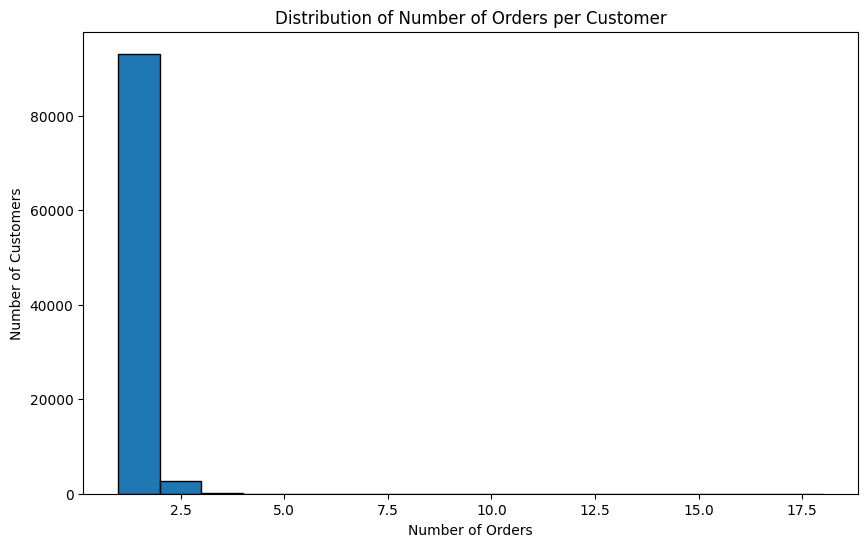

In [46]:

customer_order_counts = df['customers'].groupby('customer_unique_id')['customer_id'].count()
plt.figure(figsize=(10, 6))
plt.hist(customer_order_counts, bins=range(1, customer_order_counts.max() + 2), edgecolor='black')
plt.title('Distribution of Number of Orders per Customer')  
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')   
plt.show()

In [47]:
if customer_order_counts.max() > 1:
    print("Some customers have placed multiple orders.")

Some customers have placed multiple orders.


In [48]:
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

df_orders = df_orders.sort_values(['customer_unique_id', 'order_purchase_timestamp'])

df_orders['time_diff'] = df_orders.groupby('customer_unique_id')['order_purchase_timestamp'].diff().dt.total_seconds() / 3600

result = df_orders.groupby('customer_unique_id')['time_diff'].agg(
    avg_time_diff='mean',
    median_time_diff='median'
).dropna()

print(result)

                                  avg_time_diff  median_time_diff
customer_unique_id                                               
00172711b30d52eea8b313a7f2cced02     392.838333        392.838333
004288347e5e88a27ded2bb23747066c    4097.397500       4097.397500
004b45ec5c64187465168251cd1c9c2f    6415.523611       6415.523611
0058f300f57d7b93c477a131a59b36c3     744.968611        744.968611
00a39521eb40f7012db50455bf083460     253.976667        253.976667
...                                         ...               ...
ff36be26206fffe1eb37afd54c70e18b     310.405694        310.405694
ff44401d0d8f5b9c54a47374eb48c1b8       0.000000          0.000000
ff8892f7c26aa0446da53d01b18df463    4471.274722       4471.274722
ff922bdd6bafcdf99cb90d7f39cea5b3    2448.978056       2448.978056
ffe254cc039740e17dd15a5305035928       0.000000          0.000000

[2997 rows x 2 columns]


In [57]:
df_orders['time_diff_days'] = df_orders.groupby('customer_unique_id')['order_purchase_timestamp'].diff().dt.total_seconds() / (3600 * 24)

first_to_second_gaps_days = df_orders.dropna(subset=['time_diff_days']).groupby('customer_unique_id')['time_diff_days'].first()

avg_gap_days = first_to_second_gaps_days.mean()
median_gap_days = first_to_second_gaps_days.median()

print(f"Average time gap (1st to 2nd order): {avg_gap_days:.2f} days")
print(f"Median time gap (1st to 2nd order): {median_gap_days:.2f} days")

Average time gap (1st to 2nd order): 80.35 days
Median time gap (1st to 2nd order): 27.92 days


In [58]:
df_orders['order_number'] = df_orders.groupby('customer_unique_id').cumcount() + 1


gaps_2_3 = df_orders[df_orders['order_number'] == 3]['time_diff_days']
gaps_3_4 = df_orders[df_orders['order_number'] == 4]['time_diff_days']

print(f"2nd to 3rd Order Gap -> Avg: {gaps_2_3.mean():.2f} days | Median: {gaps_2_3.median():.2f} days")
print(f"3rd to 4th Order Gap -> Avg: {gaps_3_4.mean():.2f} days | Median: {gaps_3_4.median():.2f} days")

2nd to 3rd Order Gap -> Avg: 60.63 days | Median: 32.02 days
3rd to 4th Order Gap -> Avg: 65.95 days | Median: 32.30 days


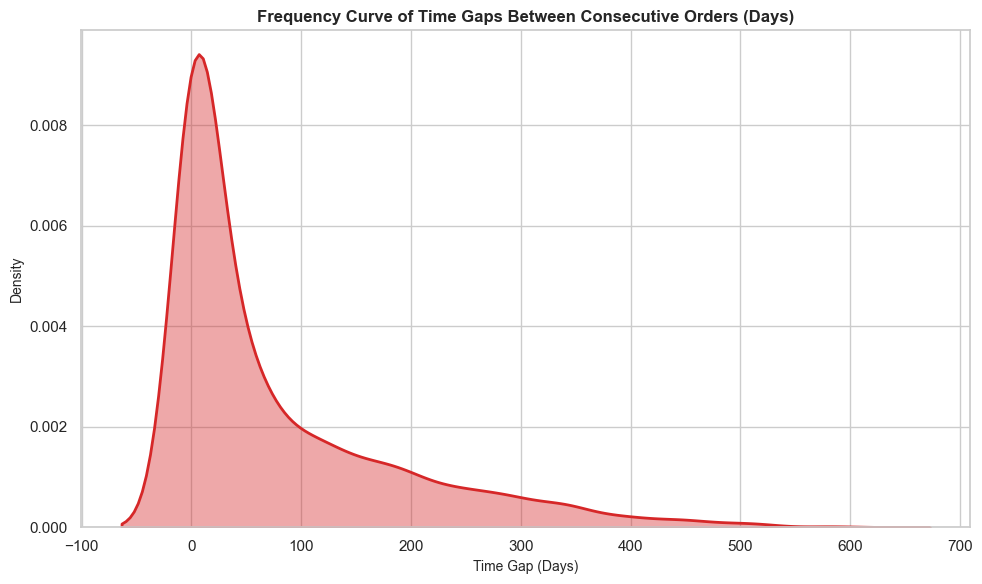

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))


valid_gaps = df_orders['time_diff_days'].dropna()
sns.kdeplot(valid_gaps, fill=True, color='#d62728', alpha=0.4, linewidth=2)
plt.title('Frequency Curve of Time Gaps Between Consecutive Orders (Days)', fontsize=12, fontweight='bold')
plt.xlabel('Time Gap (Days)', fontsize=10)
plt.ylabel('Density', fontsize=10)

plt.tight_layout()
plt.show()

                Customer Count  Percentage (%)
customer_state                                
SP                       41746       41.980672
RJ                       12852       12.924247
MG                       11635       11.700405
RS                        5466        5.496727
PR                        5045        5.073360
SC                        3637        3.657445
BA                        3380        3.399000
DF                        2140        2.152030
ES                        2033        2.044428
GO                        2020        2.031355


C:\Users\Administrator\AppData\Local\Temp\ipykernel_19148\2620968101.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.index, y=state_counts.values, palette='viridis')


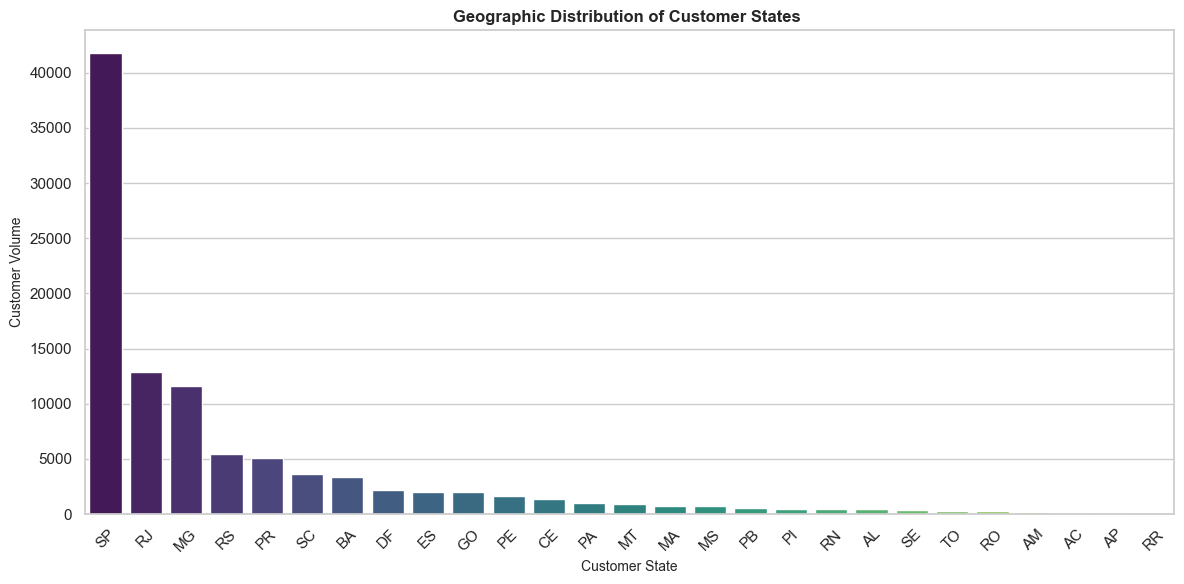

In [ ]:
state_counts = df['customers']['customer_state'].value_counts()
state_percentage = df['customers']['customer_state'].value_counts(normalize=True) * 100


distribution_summary = pd.DataFrame({
    'Customer Count': state_counts,
    'Percentage (%)': state_percentage
})
print(distribution_summary.head(10))


sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(x=state_counts.index, y=state_counts.values, palette='viridis')

plt.title('Geographic Distribution of Customer States   ', fontsize=12, fontweight='bold')
plt.xlabel('Customer State', fontsize=10)
plt.ylabel('Customer Volume', fontsize=10)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

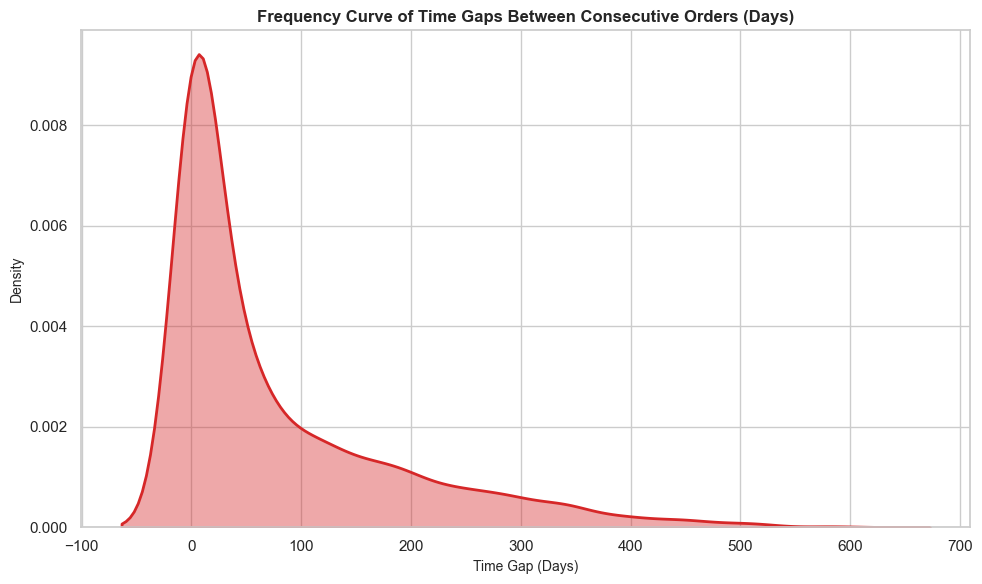

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))


valid_gaps = df_orders['time_diff_days'].dropna()
sns.kdeplot(valid_gaps, fill=True, color='#d62728', alpha=0.4, linewidth=2)
plt.title('Frequency Curve of Time Gaps Between Consecutive Orders (Days)', fontsize=12, fontweight='bold')
plt.xlabel('Time Gap (Days)', fontsize=10)
plt.ylabel('Density', fontsize=10)

plt.tight_layout()
plt.show()